In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = sns.load_dataset("tips")
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB



---
# Line plot
- A line plot visualizes how a continuous variable changes with respect to another ordered variable, most commonly time, index, or sequence.

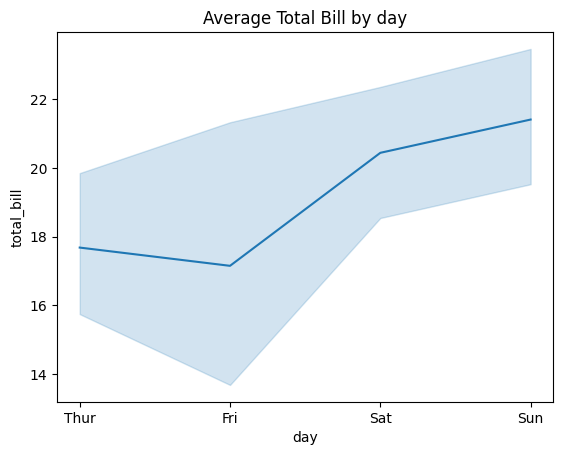

In [6]:
sns.lineplot(
    data=df,
    x="day",
    y="total_bill"
)
plt.title("Average Total Bill by day")
plt.show()

What this bar plot means is 
- Mean total bill per day, with uncertainty

This is statistical aggregation, not raw plotting.

Seaborn is built for **statistical aggregation**, meaning it automatically looks at all the data points for "Thursday," calculates their average (), and plots that single point for you behind the scenes.

Below is how we do it in Matplotlib

/tmp/ipykernel_661249/1339123589.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill = df.groupby("day")["total_bill"].mean()


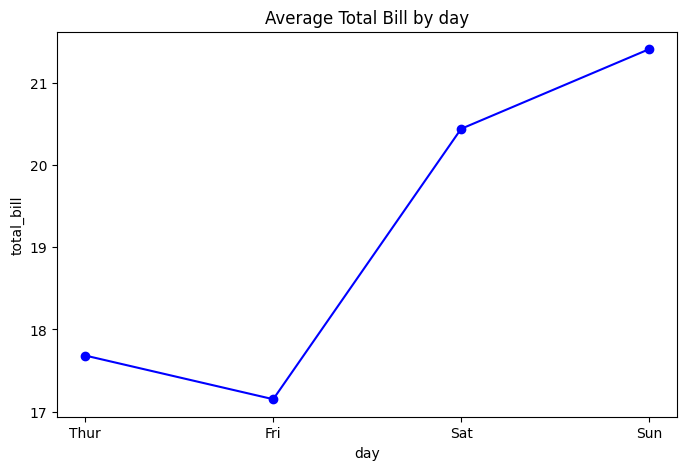

In [8]:
df = sns.load_dataset("tips")

# 1. Group by 'day' and calculate the mean of 'total_bill'
# We sort_values to ensure the days appear in a logical order (Thur -> Sun)
avg_bill = df.groupby("day")["total_bill"].mean()

# 2. Create the plot
plt.figure(figsize=(8, 5))
plt.plot(avg_bill.index, avg_bill.values, marker='o', linestyle='-', color='b')

# 3. Add labels and title
plt.xlabel("day")
plt.ylabel("total_bill")
plt.title("Average Total Bill by day")

# 4. Show the plot
plt.show()

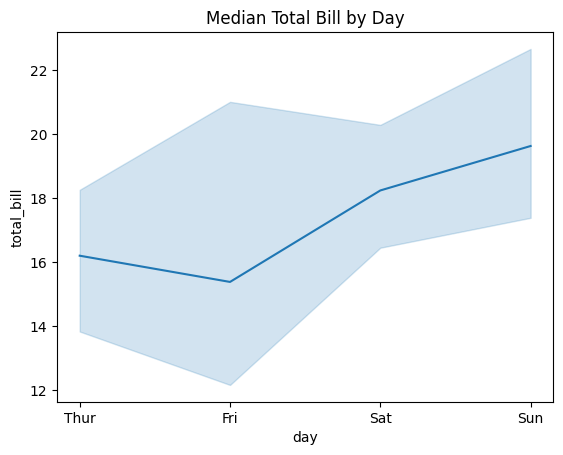

In [9]:
# how to change it to mean. just for demo
# Change the estimator to 'median'
sns.lineplot(data=df, x="day", y="total_bill", estimator="median")

plt.title("Median Total Bill by Day")
plt.show()

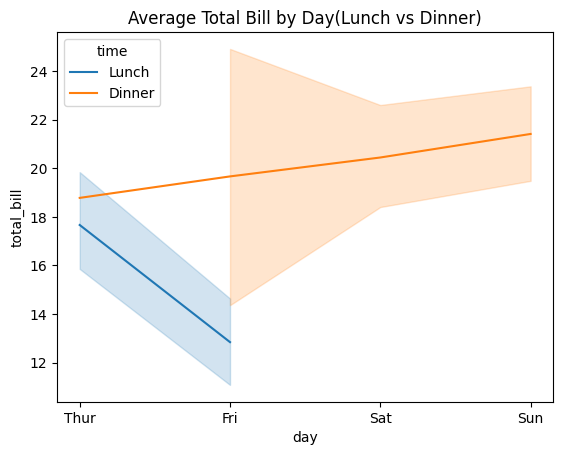

In [17]:
# Now lets compare Lunch vs Dinner trends
sns.lineplot(
    data=df,
    x="day",
    y="total_bill",
    hue="time"
)
plt.title("Average Total Bill by Day(Lunch vs Dinner)")
plt.show()

**Line plot** → use when the x-axis is **ordered/continuous** (time, index, epoch) and you want to show a **trend or change over sequence**.

**Bar plot** → use when the x-axis is **categorical (unordered)** and you want to **compare aggregated values across categories**.


# Scatter plot
Scatter plot → use when you want to analyze the relationship, correlation, or pattern between two continuous variables where points are not inherently ordered and should not be connected.

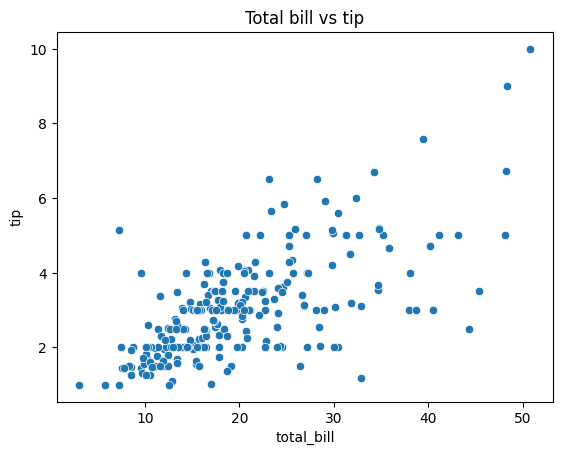

In [19]:
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip"
)
plt.title("Total bill vs tip")
plt.show()

- Positive correlation (higher bill → higher tip)

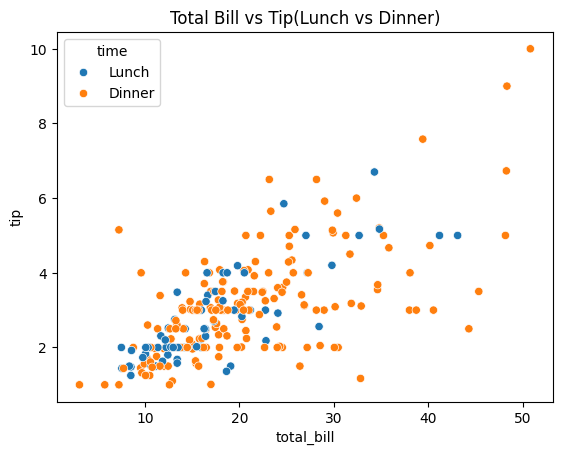

In [20]:
# Scatter plot with a third variable 
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="time"
)
plt.title("Total Bill vs Tip(Lunch vs Dinner)")
plt.show()

Why NOT Line Plot Here?
- Bills are not ordered
- Customers are independent observations
- Connecting points would imply a false sequence